In [15]:
# Block: DATA DOWNLOAD + BASIC CLEANING
# Run in Jupyter/VSCode. Requires: pip install yfinance arch scipy pandas numpy matplotlib statsmodels

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta

# ---------- USER INPUT ----------
# Replace or extend this list with the assets you want to monitor
TICKERS = ["SPY","QQQ","TLT","LQD","HYG","VNQ","GLD","BTC-USD"]  # example balanced universe
MARKET_TICKER = "SPY"      # market proxy for Treynor
RISK_FREE_RATE = 0.02      # annual risk-free (use live T-bill yield for production)
END_DATE = pd.Timestamp.today().normalize()
START_DATE = END_DATE - pd.DateOffset(years=5)  # last 5 years

# ---------- DOWNLOAD ----------
raw = yf.download(list(set(TICKERS + [MARKET_TICKER])),
                  start=START_DATE.strftime("%Y-%m-%d"),
                  end=END_DATE.strftime("%Y-%m-%d"),
                  auto_adjust=True, progress=False)

prices = raw.get('Close', raw).copy()
prices = prices.dropna(axis=1, how='all').ffill().dropna(how='all')
volumes = raw.get('Volume', None)
if volumes is not None:
    volumes = volumes[prices.columns].copy().ffill()

# ---------- RETURNS ----------
rets = prices.pct_change().dropna()   # daily simple returns
logrets = np.log(prices).diff().dropna()  # if you want log returns (for arch use often %*100)

# quick sanity
print("Data range:", prices.index.min().date(), "->", prices.index.max().date())
print("Tickers used:", list(prices.columns))
print("Price shape:", prices.shape)


Data range: 2020-10-17 -> 2025-10-16
Tickers used: ['BTC-USD', 'GLD', 'HYG', 'LQD', 'QQQ', 'SPY', 'TLT', 'VNQ']
Price shape: (1826, 8)


In [16]:
# Block A: static metrics over the full 5-year window
import statsmodels.api as sm

def ann_sharpe(ret_series, rf=RISK_FREE_RATE):
    r = ret_series.dropna()
    excess_ann = r.mean() * 252 - rf
    vol_ann = r.std() * np.sqrt(252)
    return excess_ann / (vol_ann + 1e-12)

def ann_vol(ret_series):
    return ret_series.dropna().std() * np.sqrt(252)

def compute_beta(asset_rets, market_rets):
    df = pd.concat([asset_rets, market_rets], axis=1).dropna()
    if df.shape[0] < 60:
        return np.nan
    y = df.iloc[:,0].values
    x = sm.add_constant(df.iloc[:,1].values)
    model = sm.OLS(y, x).fit()
    return model.params[1]

def max_drawdown(price_series):
    curve = (price_series / price_series.iloc[0])
    peak = curve.cummax()
    dd = curve / peak - 1
    return dd.min()

market_rets = rets[MARKET_TICKER]

rows = []
for t in prices.columns:
    if t == MARKET_TICKER: continue
    r = rets[t]
    rows.append({
        "Ticker": t,
        "Sharpe(ann)": ann_sharpe(r),
        "AnnVol": ann_vol(r),
        "Beta": compute_beta(r, market_rets),
        "Treynor": (r.mean()*252 - RISK_FREE_RATE) / (compute_beta(r, market_rets) + 1e-12),
        "MaxDD": max_drawdown(prices[t]),
        "TotalROI": prices[t].iloc[-1] / prices[t].iloc[0] - 1
    })

metrics_df = pd.DataFrame(rows).set_index("Ticker").sort_values("Sharpe(ann)", ascending=False)
metrics_df.round(4)



,Sharpe(ann),AnnVol,Beta,Treynor,MaxDD,TotalROI
Ticker,,,,,,
BTC-USD,0.8277,0.4940,1.1751,0.3480,-0.7663,8.525
GLD,0.7804,0.1260,0.1093,0.8995,NaN,NaN
QQQ,0.5581,0.1892,1.2438,0.0849,NaN,NaN
VNQ,0.2339,0.1588,0.7746,0.0480,NaN,NaN
HYG,0.1967,0.0629,0.3327,0.0372,NaN,NaN
LQD,-0.2476,0.0726,0.1811,-0.0993,NaN,NaN
TLT,-0.5105,0.1344,0.0488,-1.4064,NaN,NaN


In [17]:
pip install arch

In [18]:
# Block B: GARCH(1,1) fits (using arch package)
from arch import arch_model

garch_results = {}
forecast_horizon_days = 5

for t in prices.columns:
    # use daily percentage returns for GARCH (scale *100 for arch)
    r = (prices[t].pct_change().dropna() * 100).dropna()
    if len(r) < 250:  # need enough obs
        garch_results[t] = {"model": None, "cond_vol_ann": np.nan, "fc_vol_ann": np.nan}
        continue
    am = arch_model(r, vol='Garch', p=1, q=1, mean='Zero', dist='normal')
    try:
        res = am.fit(disp='off')
    except Exception as e:
        garch_results[t] = {"model": None, "cond_vol_ann": np.nan, "fc_vol_ann": np.nan}
        continue
    # last conditional volatility (in percent), convert to decimal and annualize
    cond_vol_pct = res.conditional_volatility.iloc[-1]    # percent
    cond_vol_daily = cond_vol_pct / 100.0
    cond_vol_ann = cond_vol_daily * np.sqrt(252)
    # forecast 1-day ahead variance, convert to vol annualized
    fc = res.forecast(horizon=forecast_horizon_days, reindex=False)
    try:
        var_1 = fc.variance.values[-1, 0]    # percent^2
        vol_1_daily = np.sqrt(var_1) / 100.0
        vol_1_ann = vol_1_daily * np.sqrt(252)
    except Exception:
        vol_1_ann = np.nan

    garch_results[t] = {"model": res, "cond_vol_ann": cond_vol_ann, "fc_vol_ann": vol_1_ann}

# Create a DataFrame summary
garch_df = pd.DataFrame({k: {"cond_vol_ann": v["cond_vol_ann"], "fc_vol_ann": v["fc_vol_ann"]}
                         for k,v in garch_results.items()}).T
garch_df.round(4)


,cond_vol_ann,fc_vol_ann
BTC-USD,0.4197,0.4188
GLD,0.1521,0.1622
HYG,0.0426,0.0439
LQD,0.0467,0.0468
QQQ,0.1759,0.1710
SPY,0.1322,0.1308
TLT,0.0983,0.0989
VNQ,0.1261,0.1251


In [19]:
# Block C: VaR and CVaR (95%)
def hist_var(r, p=0.95):
    return -np.percentile(r.dropna(), (1-p)*100)

def hist_cvar(r, p=0.95):
    cutoff = np.percentile(r.dropna(), (1-p)*100)
    tail = r[r <= cutoff]
    return -tail.mean() if len(tail) > 0 else np.nan

var_rows = []
for t in prices.columns:
    r = rets[t].dropna()
    var_95_daily = hist_var(r, 0.95)
    cvar_95_daily = hist_cvar(r, 0.95)
    var_rows.append({
        "Ticker": t,
        "VaR95_daily": var_95_daily,
        "CVaR95_daily": cvar_95_daily,
        "VaR95_ann_approx": var_95_daily * np.sqrt(252),
        "CVaR95_ann_approx": cvar_95_daily * np.sqrt(252)
    })
var_df = pd.DataFrame(var_rows).set_index("Ticker").sort_values("VaR95_daily")
var_df.round(6)


,VaR95_daily,CVaR95_daily,VaR95_ann_approx,CVaR95_ann_approx
Ticker,,,,
HYG,0.006070,0.009722,0.096353,0.154327
LQD,0.007996,0.011147,0.126935,0.176948
GLD,0.012850,0.018905,0.203980,0.300115
SPY,0.014010,0.022039,0.222403,0.349853
TLT,0.014944,0.019880,0.237236,0.315581
VNQ,0.016590,0.024432,0.263358,0.387850
QQQ,0.020167,0.029430,0.320138,0.467181
BTC-USD,0.047141,0.070173,0.748336,1.113958


In [20]:
# Block D: allocation helpers

import cvxpy as cp   # if cvxpy not available, the fallback uses scipy.minimize
from scipy.optimize import minimize

def vol_target_weights(ann_vols, target_vol=0.08):
    """
    Simple volatility targeting by risk parity-ish scaling:
    w_i proportional to 1/vol_i then scaled so portfolio vol == target_vol.
    This results in lower weights for high-vol assets.
    """
    inv = 1.0 / (ann_vols + 1e-12)
    w_raw = inv / np.nansum(inv)
    # scale to reach target volatility: portfolio vol = sqrt(w' Sigma w)
    # we approximate Sigma by (ann_vols^2) when off-diagonals unknown -> conservative
    # Better: compute full covariance when available.
    return pd.Series(w_raw, index=ann_vols.index)

def optimize_sharpe_with_constraints(mu, cov, vol_cap=None, cvar_cap=None):
    """
    Maximize Sharpe (mu' w - rf) / sqrt(w' cov w) subject to w >=0, sum(w)=1,
    and optional vol cap (sqrt(w'cov w) <= vol_cap). cvar_cap omitted for simplicity (needs scenario-based).
    """
    n = len(mu)
    x0 = np.ones(n) / n
    bounds = [(0,1)]*n
    cons = ({"type":"eq","fun": lambda w: np.sum(w)-1},)
    if vol_cap is not None:
        cons = cons + ({"type":"ineq", "fun": lambda w, cov=cov, vol_cap=vol_cap: vol_cap - np.sqrt(w @ cov @ w)},)
    def neg_sharpe(w, mu=mu, cov=cov):
        num = np.dot(w, mu) - RISK_FREE_RATE
        den = np.sqrt(w @ cov @ w) + 1e-12
        return - num / den
    res = minimize(neg_sharpe, x0, bounds=bounds, constraints=cons, method="SLSQP", options={"maxiter":500})
    w = res.x if res.success else x0
    w = np.clip(w, 0, 1)
    return w / w.sum()

# Example compute mu and cov from recent lookback window
lookback_days = 252 * 2  # 2-year lookback
recent = rets.iloc[-lookback_days:]
mu = recent.mean() * 252
cov = recent.cov() * 252

ann_vols = recent.std() * np.sqrt(252)
w_voltarget = vol_target_weights(ann_vols, target_vol=0.08)
w_sharpe_constrained = pd.Series(optimize_sharpe_with_constraints(mu[ann_vols.index].values, cov.loc[ann_vols.index, ann_vols.index].values, vol_cap=0.12),
                                 index=ann_vols.index)

print("Vol-target weights (pro-rated):\n", w_voltarget.round(4))
print("Constrained Sharpe weights:\n", w_sharpe_constrained.round(4))


Vol-target weights (pro-rated):
 Ticker
BTC-USD    0.0337
GLD        0.0891
HYG        0.2985
LQD        0.2202
QQQ        0.0678
SPY        0.0850
TLT        0.1138
VNQ        0.0919
dtype: float64
Constrained Sharpe weights:
 Ticker
BTC-USD    0.0442
GLD        0.4788
HYG        0.4770
LQD        0.0000
QQQ        0.0000
SPY        0.0000
TLT        0.0000
VNQ        0.0000
dtype: float64


In [21]:
# Block E: walk-forward backtest skeleton (quarterly rebalance)
rebalance_dates = rets.resample("Q").last().index
results = []

for i, t in enumerate(rebalance_dates[:-1]):
    train_start = t - pd.DateOffset(years=2)
    train_end = t - pd.Timedelta(days=1)
    train = rets.loc[train_start:train_end].dropna(axis=1, how='all')
    if len(train) < 252:
        continue

    # compute inputs
    mu = train.mean() * 252
    cov = train.cov() * 252
    ann_vols = train.std() * np.sqrt(252)

    # compute allocations
    wt_vol = vol_target_weights(ann_vols)
    wt_sharpe = pd.Series(optimize_sharpe_with_constraints(mu.values, cov.values, vol_cap=0.12), index=mu.index)

    # next period returns (apply from t to next rebalance)
    next_t = rebalance_dates[i+1]
    period_rets = rets.loc[t:next_t].dropna(axis=1, how='all')

    # align weights to available assets in period_rets
    wt_vol_aligned = wt_vol.reindex(period_rets.columns).fillna(0)
    wt_vol_aligned = wt_vol_aligned / wt_vol_aligned.sum()

    wt_sharpe_aligned = wt_sharpe.reindex(period_rets.columns).fillna(0)
    wt_sharpe_aligned = wt_sharpe_aligned / wt_sharpe_aligned.sum()

    port_vol_returns = (period_rets * wt_vol_aligned).sum(axis=1)
    port_sharpe_returns = (period_rets * wt_sharpe_aligned).sum(axis=1)

    # realized metrics
    def port_stats(pr):
        ann_ret = (1+pr).prod() ** (252/len(pr)) - 1
        ann_vol = pr.std() * np.sqrt(252)
        sharpe = (pr.mean()*252 - RISK_FREE_RATE)/(ann_vol + 1e-12)
        maxdd = (1+pr).cumprod().div((1+pr).cumprod().cummax()).min() - 1
        return ann_ret, ann_vol, sharpe, maxdd

    vol_stats = port_stats(port_vol_returns)
    sharpe_stats = port_stats(port_sharpe_returns)

    # fault checks: compare realized vol for each asset in period to GARCH fc from train
    faults = []
    for a in period_rets.columns:
        # predicted (1-day ahead annualized) vol from GARCH fit on train
        g = garch_results.get(a, {})
        pred = g.get("fc_vol_ann", np.nan)
        realized = period_rets[a].std() * np.sqrt(252)
        if pd.notna(pred) and pd.notna(realized) and pred > 0 and realized > 2.0 * pred:
            faults.append({"asset": a, "pred_vol": pred, "real_vol": realized, "ratio": realized/pred})

    results.append({
        "rebalance": t,
        "wt_vol": wt_vol_aligned,
        "wt_sharpe": wt_sharpe_aligned,
        "vol_stats": vol_stats,
        "sharpe_stats": sharpe_stats,
        "faults": faults,
        "period_rets_index": period_rets.index
    })

# Aggregate performance curves for the whole backtest
def concat_ports(series_list):
    if not series_list: return pd.Series(dtype=float)
    return pd.concat(series_list).sort_index()

vol_port_daily = concat_ports([ (rets.loc[r["period_rets_index"], :] * r["wt_vol"]).sum(axis=1) for r in results ])
# Simplify: build cumulative by re-summing per-period returns
vol_curves = []
sh_curves = []
for r in results:
    pr_vol = (rets.loc[r["period_rets_index"], r["wt_vol"].index] * r["wt_vol"]).sum(axis=1)
    pr_sh = (rets.loc[r["period_rets_index"], r["wt_sharpe"].index] * r["wt_sharpe"]).sum(axis=1)
    vol_curves.append((1+pr_vol).cumprod())
    sh_curves.append((1+pr_sh).cumprod())

# Concatenate piecewise:
if vol_curves:
    vol_full = pd.concat(vol_curves).sort_index()
else:
    vol_full = pd.Series(dtype=float)
if sh_curves:
    sh_full = pd.concat(sh_curves).sort_index()
else:
    sh_full = pd.Series(dtype=float)

In [22]:
import pandas as pd

summary_data = []
for r in results:
    summary_data.append({
        "Rebalance Date": r["rebalance"],
        "Vol Target Ann Ret": r["vol_stats"][0],
        "Vol Target Ann Vol": r["vol_stats"][1],
        "Vol Target Sharpe": r["vol_stats"][2],
        "Vol Target MaxDD": r["vol_stats"][3],
        "Sharpe Constrained Ann Ret": r["sharpe_stats"][0],
        "Sharpe Constrained Ann Vol": r["sharpe_stats"][1],
        "Sharpe Constrained Sharpe": r["sharpe_stats"][2],
        "Sharpe Constrained MaxDD": r["sharpe_stats"][3],
    })

summary_df = pd.DataFrame(summary_data).set_index("Rebalance Date")
display(summary_df.round(4))

,Vol Target Ann Ret,Vol Target Ann Vol,Vol Target Sharpe,Vol Target MaxDD,Sharpe Constrained Ann Ret,Sharpe Constrained Ann Vol,Sharpe Constrained Sharpe,Sharpe Constrained MaxDD
Rebalance Date,,,,,,,,
2021-06-30,0.0194,0.0446,0.0055,-0.0300,0.0755,0.0988,0.5838,-0.0632
2021-09-30,0.1206,0.0509,1.8680,-0.0224,0.2894,0.1146,2.1006,-0.0499
2021-12-31,-0.1400,0.0835,-2.0039,-0.0891,-0.1311,0.1526,-0.9765,-0.1278
2022-03-31,-0.3180,0.1256,-3.1408,-0.1463,-0.4553,0.2001,-3.0315,-0.2213
2022-06-30,-0.1517,0.1151,-1.5461,-0.1256,-0.2202,0.1457,-1.7718,-0.1633
2022-09-30,0.1001,0.1353,0.6235,-0.0490,0.1076,0.1636,0.5830,-0.0506
2022-12-31,0.2442,0.0890,2.2745,-0.0590,0.2027,0.1054,1.6142,-0.0679
2023-03-31,0.0869,0.0582,1.1183,-0.0277,-0.0729,0.0995,-0.9124,-0.0647
2023-06-30,-0.1088,0.0715,-1.8542,-0.0671,-0.0987,0.0743,-1.6306,-0.0677


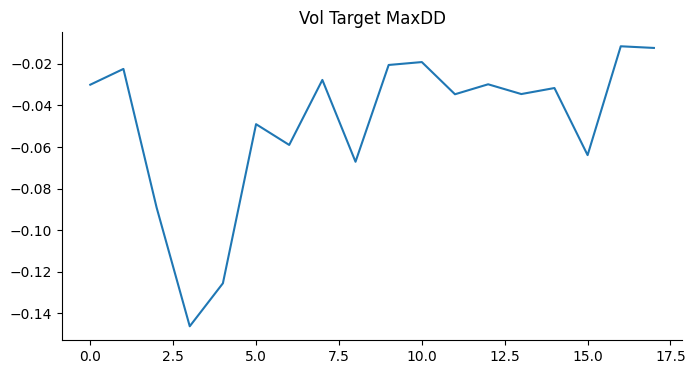

In [23]:
from matplotlib import pyplot as plt
_df_15['Vol Target MaxDD'].plot(kind='line', figsize=(8, 4), title='Vol Target MaxDD')
plt.gca().spines[['top', 'right']].set_visible(False)

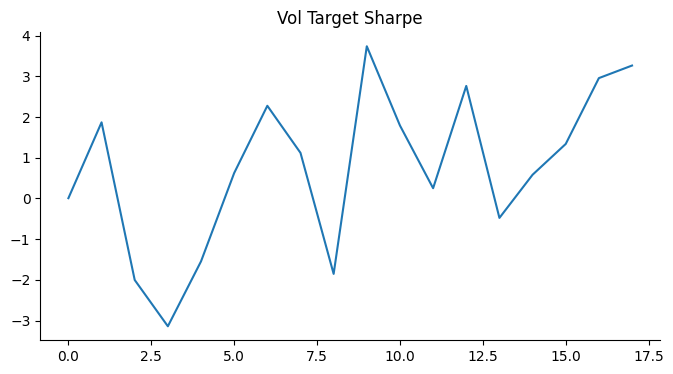

In [24]:
from matplotlib import pyplot as plt
_df_14['Vol Target Sharpe'].plot(kind='line', figsize=(8, 4), title='Vol Target Sharpe')
plt.gca().spines[['top', 'right']].set_visible(False)

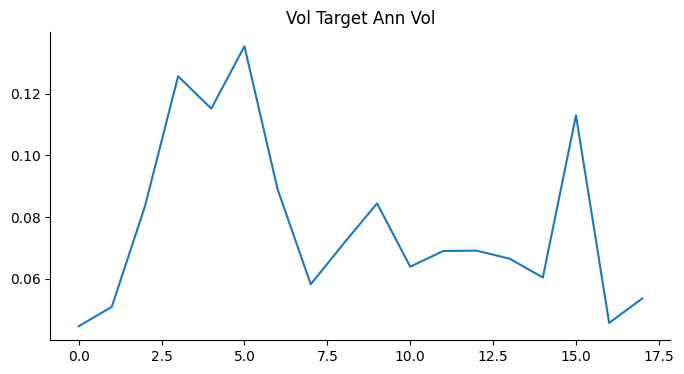

In [25]:
from matplotlib import pyplot as plt
_df_13['Vol Target Ann Vol'].plot(kind='line', figsize=(8, 4), title='Vol Target Ann Vol')
plt.gca().spines[['top', 'right']].set_visible(False)

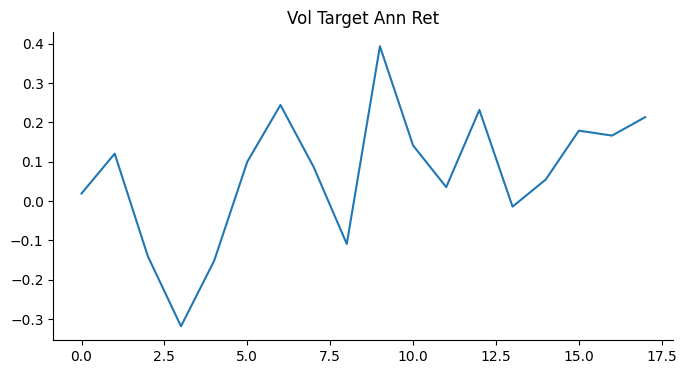

In [26]:
from matplotlib import pyplot as plt
_df_12['Vol Target Ann Ret'].plot(kind='line', figsize=(8, 4), title='Vol Target Ann Ret')
plt.gca().spines[['top', 'right']].set_visible(False)

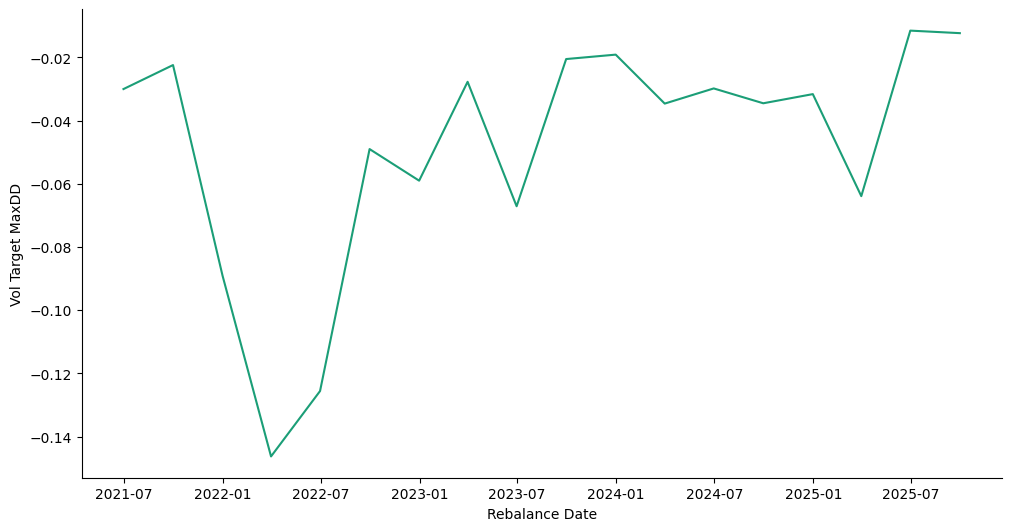

In [27]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Rebalance Date']
  ys = series['Vol Target MaxDD']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('Rebalance Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Rebalance Date')
_ = plt.ylabel('Vol Target MaxDD')

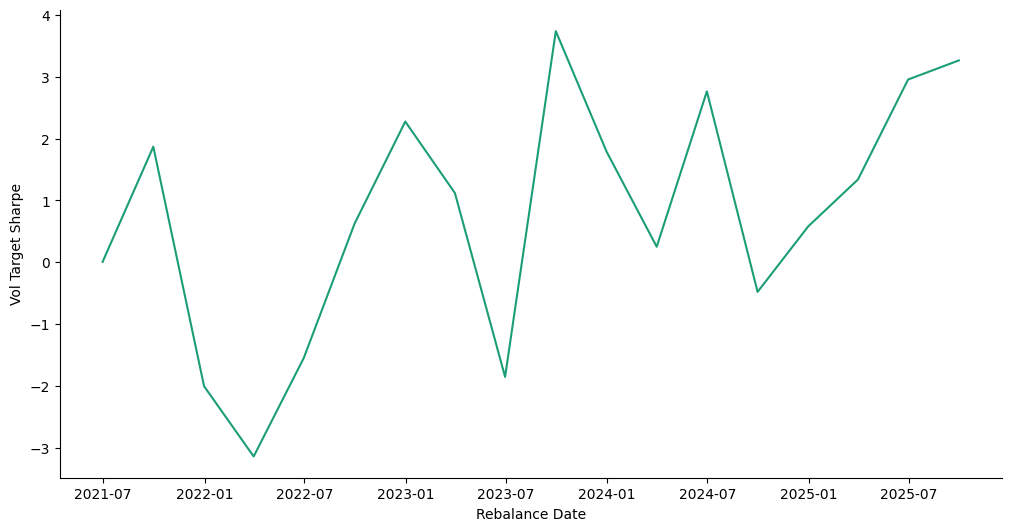

In [28]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Rebalance Date']
  ys = series['Vol Target Sharpe']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_10.sort_values('Rebalance Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Rebalance Date')
_ = plt.ylabel('Vol Target Sharpe')

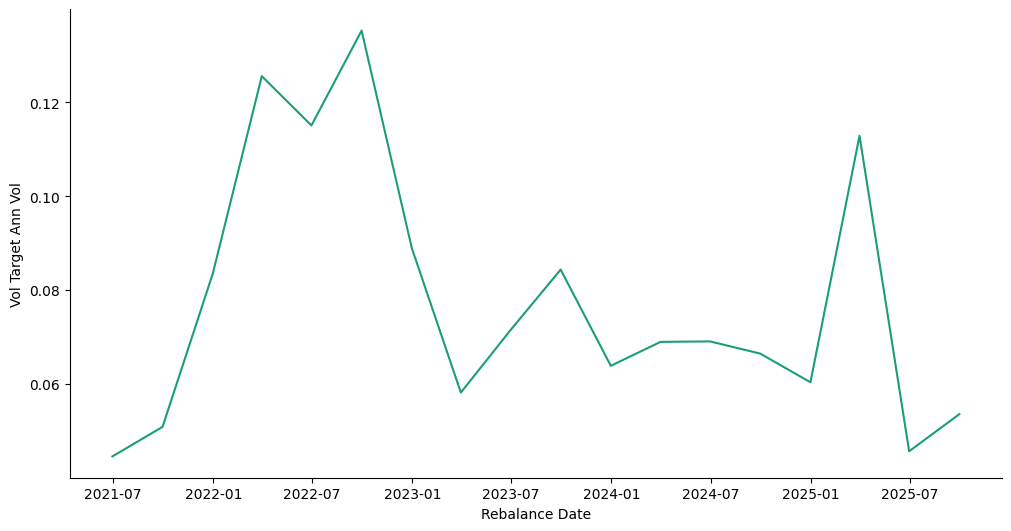

In [29]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Rebalance Date']
  ys = series['Vol Target Ann Vol']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_9.sort_values('Rebalance Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Rebalance Date')
_ = plt.ylabel('Vol Target Ann Vol')

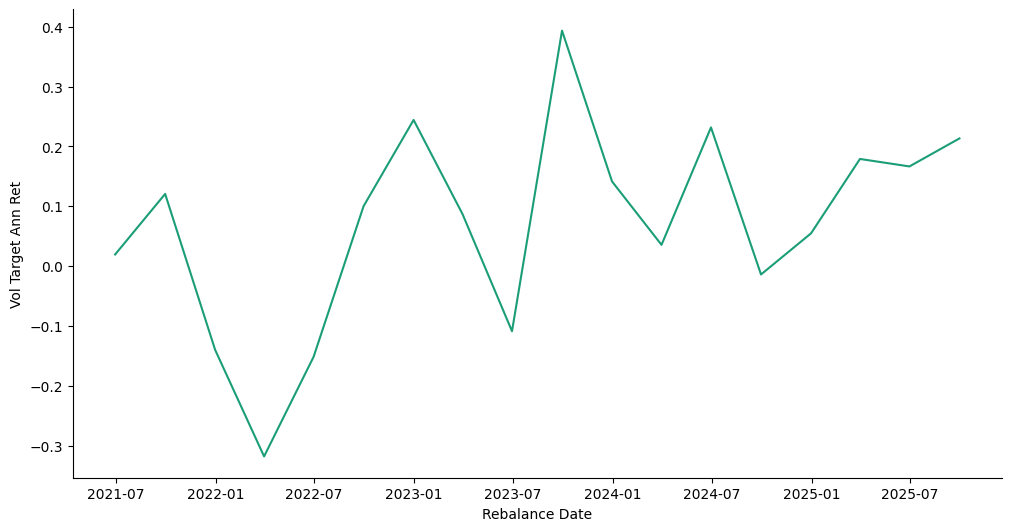

In [30]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Rebalance Date']
  ys = series['Vol Target Ann Ret']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_8.sort_values('Rebalance Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Rebalance Date')
_ = plt.ylabel('Vol Target Ann Ret')

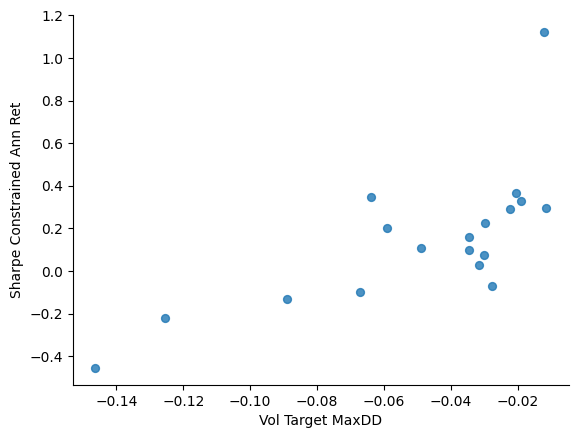

In [31]:
from matplotlib import pyplot as plt
_df_7.plot(kind='scatter', x='Vol Target MaxDD', y='Sharpe Constrained Ann Ret', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

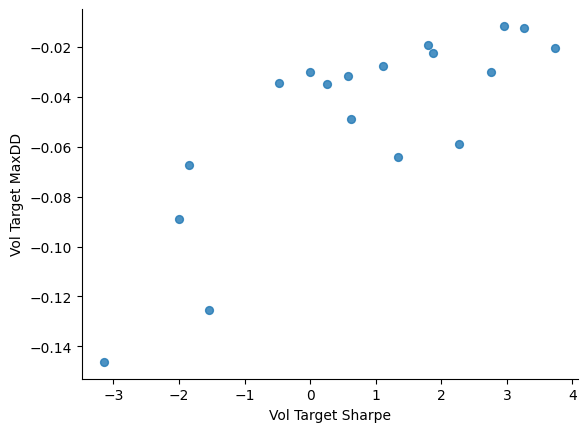

In [32]:
from matplotlib import pyplot as plt
_df_6.plot(kind='scatter', x='Vol Target Sharpe', y='Vol Target MaxDD', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

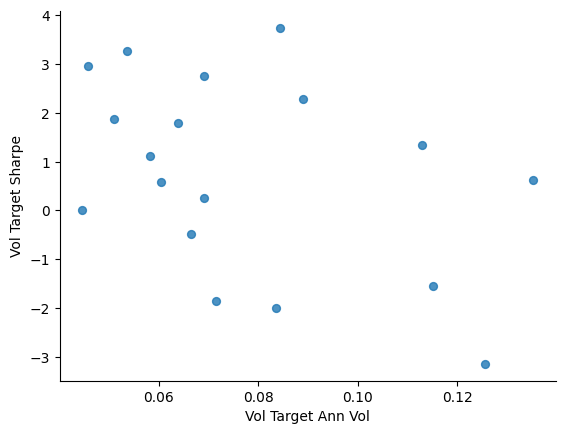

In [33]:
from matplotlib import pyplot as plt
_df_5.plot(kind='scatter', x='Vol Target Ann Vol', y='Vol Target Sharpe', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

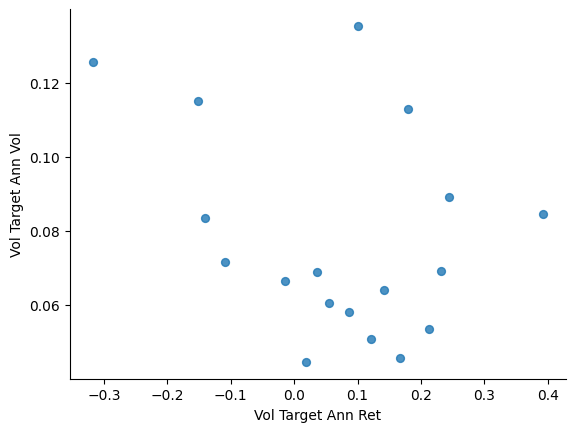

In [34]:
from matplotlib import pyplot as plt
_df_4.plot(kind='scatter', x='Vol Target Ann Ret', y='Vol Target Ann Vol', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

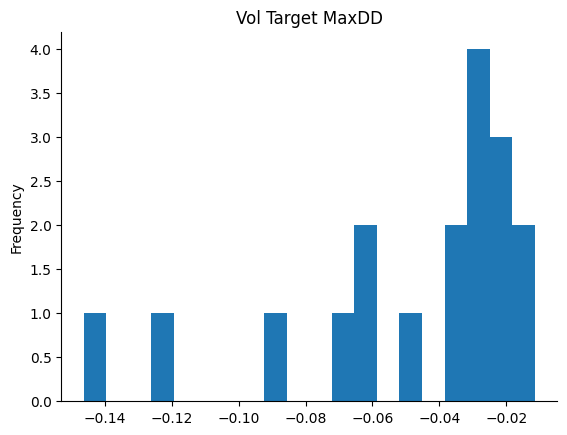

In [35]:
from matplotlib import pyplot as plt
_df_3['Vol Target MaxDD'].plot(kind='hist', bins=20, title='Vol Target MaxDD')
plt.gca().spines[['top', 'right',]].set_visible(False)

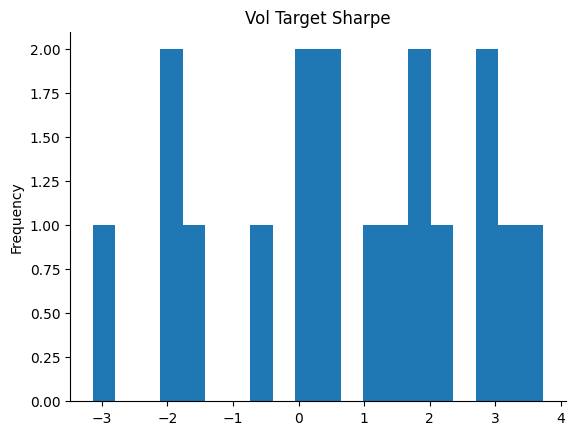

In [36]:
from matplotlib import pyplot as plt
_df_2['Vol Target Sharpe'].plot(kind='hist', bins=20, title='Vol Target Sharpe')
plt.gca().spines[['top', 'right',]].set_visible(False)

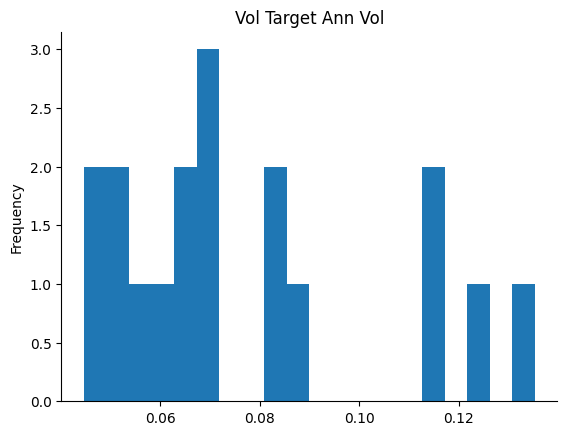

In [37]:
from matplotlib import pyplot as plt
_df_1['Vol Target Ann Vol'].plot(kind='hist', bins=20, title='Vol Target Ann Vol')
plt.gca().spines[['top', 'right',]].set_visible(False)

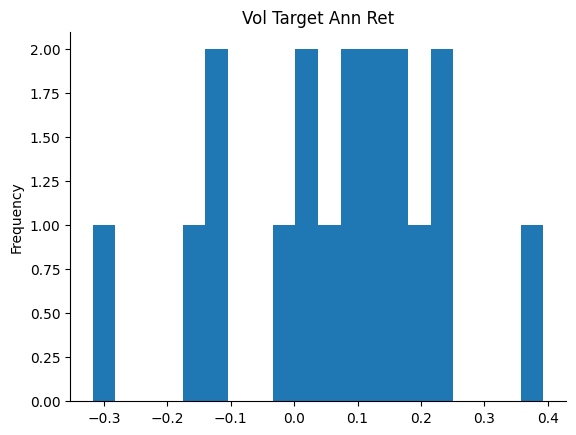

In [38]:
from matplotlib import pyplot as plt
_df_0['Vol Target Ann Ret'].plot(kind='hist', bins=20, title='Vol Target Ann Ret')
plt.gca().spines[['top', 'right',]].set_visible(False)